In [1]:
import torch
import torch.nn.functional as F
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(1024)

In [2]:
class Linear:
    # input:(B,in_features)
    # output:(B,out_features)
    def __init__(self, in_features, out_features, bias=True):
        # 对于模型参数的初始化，故意没有做优化
        self.weight = torch.randn((in_features, out_features), requires_grad=True)  # (in_features,out_features)
        if bias:
            self.bias = torch.randn(out_features, requires_grad=True)  # (out_features)
        else:
            self.bias = None

    def __call__(self, x):  # 方法让类的实例可以像函数一样被调用
        # x:  (B,in_features)
        # self.weight:(in_features,out_features)
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        # 返回模型参数
        if self.bias is not None:
            return [self.weight, self.bias]
        return self.weight

In [3]:
class Sigmoid:
    def __call__(self, x):
        self.out = torch.sigmoid(x)
        return self.out

    @staticmethod
    def parameters():
        return []

In [4]:
class Sequential:
    def __init__(self, layers):
        # layers表示的模型组件，比如线性模型，比如sigmoid
        self.layers = layers

    def __call__(self, x):
        for l in self.layers:
            x = l(x)
        self.out = x
        return self.out

    def parameters(self):
        # k=[]
        # for layer in self.layers():
        #     for p in layer.parameters():
        #          k.append(p)
        return [p for layer in self.layers for p in layer.parameters()]

    def predict_proba(self, x):
        # 计算概率预测
        if isinstance(x, np.ndarray):
            x = torch.tensor(x).float()
        logits = self(x)  # 等价于 self.__call__(x)
        self.prob = F.softmax(logits, dim=-1).detach().numpy()
        return self.prob

In [5]:
def train_model(model, data, max_steps):
    lossi = []
    # 记录各层的参数更新幅度
    # {1:[...],2:[...]}

    udi = {}
    x, y = torch.tensor(data[0]).float(), torch.tensor(data[1])
    learning_rate = 0.01

    for i in range(max_steps):
        # 前向传播
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        # 保留中间节点的梯度，以便观察
        for layer in model.layers:
            layer.out.retain_grad()
        for p in model.parameters():
            p.grad = None
        # 反向传播
        loss.backward()
        # 更新模型参数
        with torch.no_grad():
            for i, p in enumerate(model.parameters()):
                p -= learning_rate * p.grad
                udi[i] = udi.get(i, []) + [(learning_rate * p.grad).std() / p.std()]
        lossi.append(loss.item())
    return lossi, udi

In [6]:
from sklearn.datasets import make_moons

data = make_moons(2000, noise=0.05)

n_hidden = 100
model = Sequential([
    Linear(2, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, 2)
])

train_model(model, data, 1)

([0.9026815295219421],
 {0: [tensor(0.0007)],
  1: [tensor(0.0009)],
  2: [tensor(0.0003)],
  3: [tensor(0.0004)],
  4: [tensor(0.0002)],
  5: [tensor(0.0004)],
  6: [tensor(0.0002)],
  7: [tensor(0.0004)],
  8: [tensor(0.0020)],
  9: [tensor(0.0040)]})

In [7]:
def saturation_stats(model):
    for i, layer in enumerate(model.layers):
        if isinstance(layer, Sigmoid):
            t = layer.out
            # 当激活函数的输出大于0.99或者小于0.01的时候，我们就认为激活函数过热
            # 计算过热比例
            saturation = ((t - 0.5).abs() > 0.49).float().mean()
            # 激活函数的输出分布情况
            hy, hx = torch.histogram(t, density=True)
            plt.plot(hx[:-1].detach(), hy.detach())
            print(f'layer {i}: mean {t.mean():.2f} std {t.std():.2f} saturation {saturation:.2f}')
    plt.show()

layer 1: mean 0.51 std 0.27 saturation 0.01
layer 3: mean 0.52 std 0.42 saturation 0.38
layer 5: mean 0.41 std 0.43 saturation 0.45
layer 7: mean 0.54 std 0.41 saturation 0.38


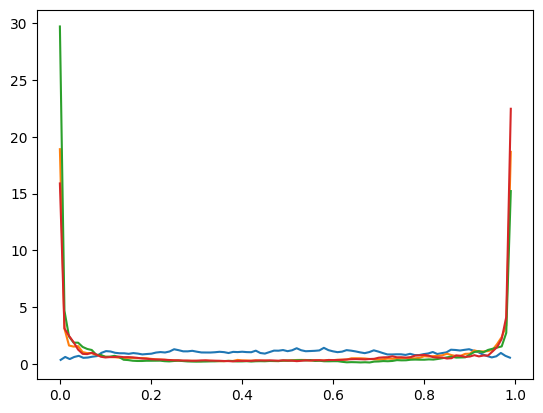

In [8]:
saturation_stats(model)

In [9]:
def grad_stats(model):
    # 输出层暂不讨论
    for i, layer in enumerate(model.layers[:-1]):
        if isinstance(layer, Linear):
            w = layer.parameters()[0]
            g=w.grad
            grad_ratio=g.std()/w.std()
            # 激活函数的输出分布情况
            hy, hx = torch.histogram(g, density=True)
            plt.plot(hx[:-1].detach(), hy.detach())
            print(f'layer {i}: mean {g.mean():.2f} std {g.std():.2f} saturation {grad_ratio:.2f}')
    plt.show()

layer 0: mean 0.00 std 0.08 saturation 0.07
layer 2: mean 0.00 std 0.03 saturation 0.03
layer 4: mean 0.00 std 0.02 saturation 0.02
layer 6: mean 0.00 std 0.02 saturation 0.02


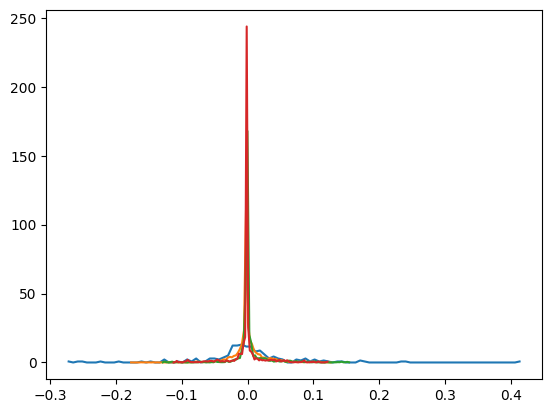

In [10]:
grad_stats(model)

In [11]:
_, ud = train_model(model, data, 100)


def grad_ratio_plot(model):
    legends = []
    for i, p in enumerate(model.parameters()[:-2]):
        if p.ndim == 2:
            plt.plot([t.log10().item() for t in ud[i]])
            legends.append(f'layer {i} {p.shape}')
    plt.legend(legends)
    plt.show()


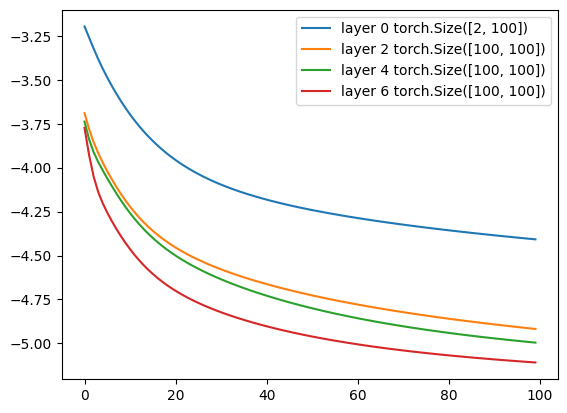

In [12]:
grad_ratio_plot(model)

In [14]:
data = make_moons(2000, noise=0.05)

n_hidden = 100
model = Sequential([
    Linear(2, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, n_hidden), Sigmoid(),
    Linear(n_hidden, 2)
])

# 参数初始化的优化
with torch.no_grad():
    for layer in model.layers:
        if isinstance(layer, Linear):
            in_features,out_features= layer.weight.shape
            layer.weight*=1/in_features**0.5
            layer.bias=torch.zeros(out_features,requires_grad=True)

train_model(model, data, 1)

([0.6956790089607239],
 {0: [tensor(1.2358e-06)],
  1: [tensor(1.)],
  2: [tensor(9.5280e-06)],
  3: [tensor(1.)],
  4: [tensor(2.0926e-05)],
  5: [tensor(1.)],
  6: [tensor(8.6499e-05)],
  7: [tensor(1.)],
  8: [tensor(0.0026)],
  9: [tensor(1.)]})

layer 1: mean 0.50 std 0.17 saturation 0.00
layer 3: mean 0.49 std 0.13 saturation 0.00
layer 5: mean 0.50 std 0.13 saturation 0.00
layer 7: mean 0.50 std 0.13 saturation 0.00


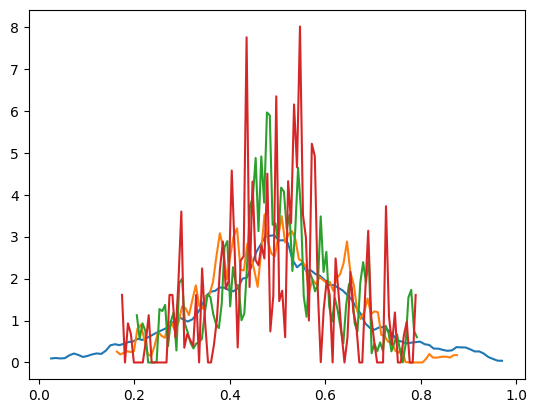

In [15]:
saturation_stats(model)

layer 0: mean 0.00 std 0.00 saturation 0.00
layer 2: mean 0.00 std 0.00 saturation 0.00
layer 4: mean 0.00 std 0.00 saturation 0.00
layer 6: mean 0.00 std 0.00 saturation 0.01


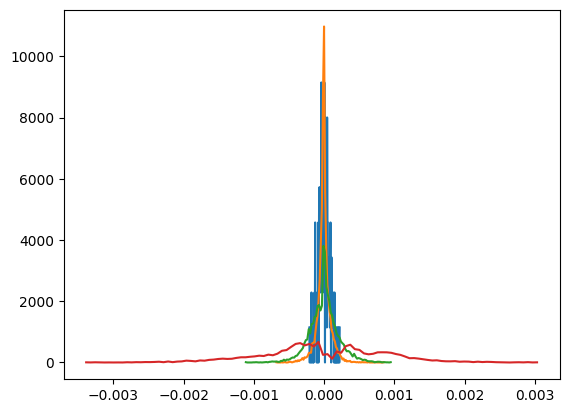

In [16]:
grad_stats(model)

In [17]:
_, ud = train_model(model, data, 100)

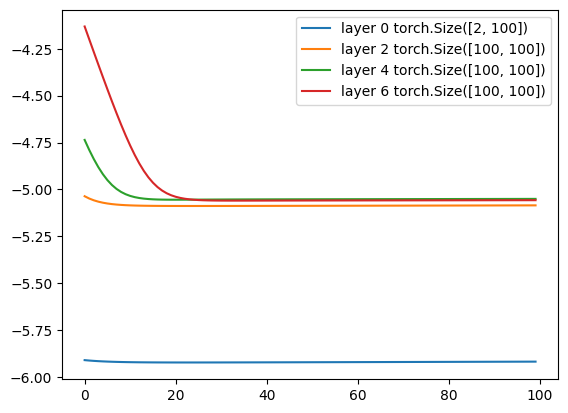

In [18]:
grad_ratio_plot(model)